In [4]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import os
import sys
# sys.path.append('/home/matanyaw/DIP_decoder/voxel_embeddings_ROIs')
from voxel_embeddings_ROIs import ROI_coverage, ROI_tsne_funcs
# Getting my modules
sys.path.append('/home/jonathak/VisualEncoder/Analysis/Brain_maps')
from NIPS_utils import get_hemisphere_indices, get_roi_indices, get_roi_indices_per_hemisphere


# Setting up GPU
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Appending Roman's path
sys.path.append('/home/romanb/PycharmProjects/BrainVisualReconst/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Loading the model
encoder = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg')
model = torch.load('/home/jonathak/VisualEncoder/Voxels_Prediction/model_ch128.pth').eval().cuda()

# Testing voxel embeddings
voxel_embeddings = model.voxel_embed # Has shape [315997, 256]

# Getting subject 1 indices

subject = 1

lh_start, lh_end = get_hemisphere_indices(subject, 'lh')
rh_start, rh_end = get_hemisphere_indices(subject, 'rh')    
sub_indices = np.arange(lh_start, rh_end)

voxel_embeddings = voxel_embeddings[sub_indices]


Using cache found in /home/matanyaw/.cache/torch/hub/facebookresearch_dinov2_main
/home/matanyaw/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/matanyaw/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/matanyaw/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [6]:
DATA_DIR = '/home/matanyaw/DIP_decoder/data'

In [33]:
coverages = ROI_coverage.load_coverages('/home/matanyaw/DIP_decoder/data/roi_coverages', exclude=['euc'])
coverages

[Predefined,
 Mean Cos NV,
 Mean Cos NV Polished,
 Meanshift Cos NC,
 Meanshift Cos NC Polished,
 Meanshift Cos NV,
 Meanshift Cos NV Polished]

In [24]:
subject = 1

ROI_names = ROI_coverage.get_roi_names(subject=subject)

predefined_ROI_indices = {}

# Creating a dictionary of ROI indices (iterating over copy because we remove ROIs that don't exist)
for ROI in ROI_names.copy():
    
    roi_indices = get_roi_indices(subject, ROI)
    
    if roi_indices is None:
        ROI_names.remove(ROI)
    else:
        predefined_ROI_indices[ROI] = roi_indices
        # print(ROI, roi_indices.shape)
# predefined_ROIless_indeices = summary_roi_coverage(predefined_ROI_indices, sub_indices)


ROI 'mTL-bodies' not found for subject 1
ROI 'mTL-faces' not found for subject 1
ROI 'aTL-faces' not found for subject 1
ROI 'mTL-words' not found for subject 1


In [25]:
roi_coverage_configs = []

roi_coverage_configs.append(ROI_coverage.InferRoiCoverageConfig(voxel_embeddings=voxel_embeddings, predefined_ROI_indices_dict=predefined_ROI_indices,
                                                                center_method=None, metric=None, discrimination_method='predefined'))

roi_coverage_configs.append(ROI_coverage.InferRoiCoverageConfig(voxel_embeddings=voxel_embeddings, predefined_ROI_indices_dict=predefined_ROI_indices,
                                                                center_method='mean', metric='euclidean', discrimination_method='nearest_voxels'))

roi_coverage_configs.append(ROI_coverage.InferRoiCoverageConfig(voxel_embeddings=voxel_embeddings, predefined_ROI_indices_dict=predefined_ROI_indices,
                                                                center_method='mean', metric='cosine', discrimination_method='nearest_voxels'))

roi_coverage_configs.append(ROI_coverage.InferRoiCoverageConfig(voxel_embeddings=voxel_embeddings, predefined_ROI_indices_dict=predefined_ROI_indices,
                                                                center_method='meanshift', metric='euclidean', discrimination_method='nearest_voxels'))


roi_coverage_configs.append(ROI_coverage.InferRoiCoverageConfig(voxel_embeddings=voxel_embeddings, predefined_ROI_indices_dict=predefined_ROI_indices,
                                                                center_method='meanshift', metric='cosine', discrimination_method='nearest_voxels'))


roi_coverage_configs.append(ROI_coverage.InferRoiCoverageConfig(voxel_embeddings=voxel_embeddings, predefined_ROI_indices_dict=predefined_ROI_indices,
                                                                center_method='meanshift', metric='euclidean', discrimination_method='nearest_center'))

roi_coverage_configs.append(ROI_coverage.InferRoiCoverageConfig(voxel_embeddings=voxel_embeddings, predefined_ROI_indices_dict=predefined_ROI_indices,
                                                                center_method='meanshift', metric='cosine', discrimination_method='nearest_center'))

In [26]:
for coverage in roi_coverage_configs:
    print(coverage.name)
    coverage.infer_roi_coverage()
    

predefined
mean_euc_nearest_voxels
mean_cos_nearest_voxels
ms_euc_nearest_voxels
ms_cos_nearest_voxels
ms_euc_nearest_center
ms_cos_nearest_center


In [27]:
polished_configs = []
for config in roi_coverage_configs:
    print(config.name)
    polished_config = config.copy()
    polished_config.clear_islands()
    polished_configs.append(polished_config)


predefined
mean_euc_nearest_voxels
mean_cos_nearest_voxels
ms_euc_nearest_voxels
ms_cos_nearest_voxels
ms_euc_nearest_center
ms_cos_nearest_center


## Save Coverages

In [28]:
roi_covs_dir = os.path.join(DATA_DIR, 'roi_coverages')
os.makedirs(roi_covs_dir, exist_ok=True)
for coverage in roi_coverage_configs + polished_configs:
    path = os.path.join(roi_covs_dir, coverage.name + '.pkl')
    coverage.save(path)

# SNR check

In [42]:
print('Average Coverage SNR:')
for cov in roi_coverage_configs:
    print(f'{cov.get_label()}\t{round(cov.get_avg_SNR("all"), 3)}')

print('\nAverage Coverage SNR Polished:')
for cov in polished_configs:
    print(f'{cov.get_label()}\t{round(cov.get_avg_SNR("all"), 3)}')

Average Coverage SNR:
Predefined	0.449
Mean Euc NV	0.222
Mean Cos NV	0.513
Meanshift Euc NV	0.228
Meanshift Cos NV	0.511
Meanshift Euc NC	0.408
Meanshift Cos NC	0.408

Average Coverage SNR Polished:
Predefined Polished	0.449
Mean Euc NV Polished	0.293
Mean Cos NV Polished	0.532
Meanshift Euc NV Polished	0.306
Meanshift Cos NV Polished	0.525
Meanshift Euc NC Polished	0.453
Meanshift Cos NC Polished	0.451


# Now let's test double polishing, does it change anything? 


In [36]:
polished_configs

[RoiInferConfig(center_method=mean, metric=euclidean, discrimination_method=predefined, ,
 RoiInferConfig(center_method=mean, metric=euclidean, discrimination_method=nearest_voxels, ,
 RoiInferConfig(center_method=mean, metric=cosine, discrimination_method=nearest_voxels, ,
 RoiInferConfig(center_method=meanshift, metric=euclidean, discrimination_method=nearest_voxels, ,
 RoiInferConfig(center_method=meanshift, metric=cosine, discrimination_method=nearest_voxels, ,
 RoiInferConfig(center_method=meanshift, metric=euclidean, discrimination_method=nearest_center, ,
 RoiInferConfig(center_method=meanshift, metric=cosine, discrimination_method=nearest_center, ]

In [ ]:
double_polished_configs = [config.copy().clear_islands() for config in polished_configs]


unpolished	polished	double
EBA


TypeError: 'int' object is not iterable

In [39]:

print('unpolished\tpolished\tdouble')
for polished, double in zip(polished_configs, double_polished_configs):
    for roi in ROI_names:
        polished_indices = polished[roi]
        double_indices = double[roi]
        difference = set(polished_indices).symmetric_difference(set(double_indices))
        if len(difference) > 0:
            print(f'Found a difference! \nin: {polished.name} vs {double.name}: {len(difference)} voxels are different')
    else: 
        print(f'{polished.name} and {double.name} are the same')

unpolished	polished	double
predefined_polished and predefined_polished_polished are the same
mean_euc_nearest_voxels_polished and mean_euc_nearest_voxels_polished_polished are the same
mean_cos_nearest_voxels_polished and mean_cos_nearest_voxels_polished_polished are the same
ms_euc_nearest_voxels_polished and ms_euc_nearest_voxels_polished_polished are the same
ms_cos_nearest_voxels_polished and ms_cos_nearest_voxels_polished_polished are the same
ms_euc_nearest_center_polished and ms_euc_nearest_center_polished_polished are the same
ms_cos_nearest_center_polished and ms_cos_nearest_center_polished_polished are the same


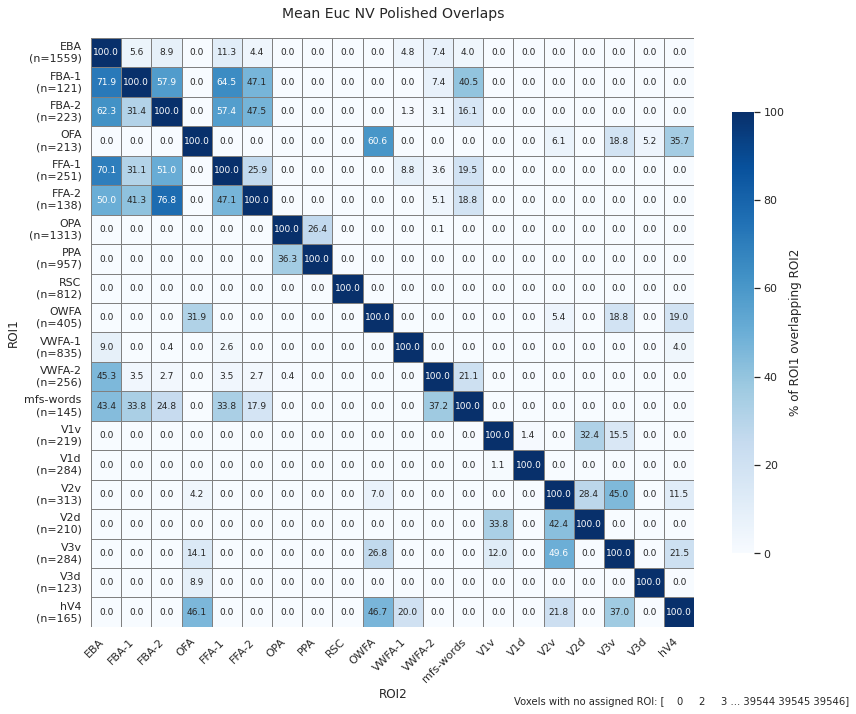

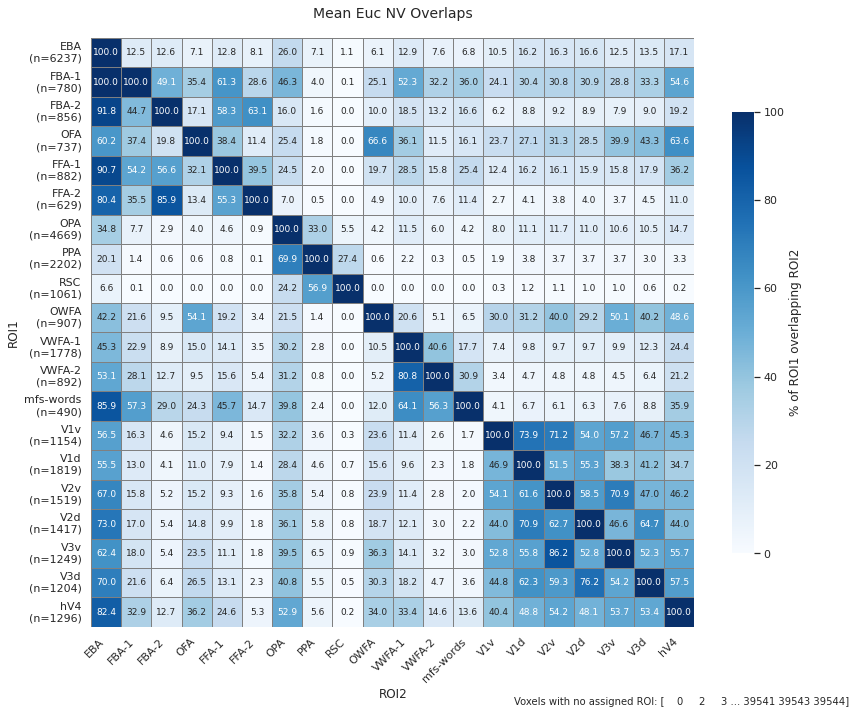

In [52]:
polished_configs[1].plot_ROI_overlap()
roi_coverage_configs[1].plot_ROI_overlap()

In [12]:
c = ROI_coverage.InferRoiCoverageConfig.load('/home/matanyaw/DIP_decoder/data/roi_coverages/ms_cos_nearest_center.pkl')
c.name

'ms_cos_nearest_center'

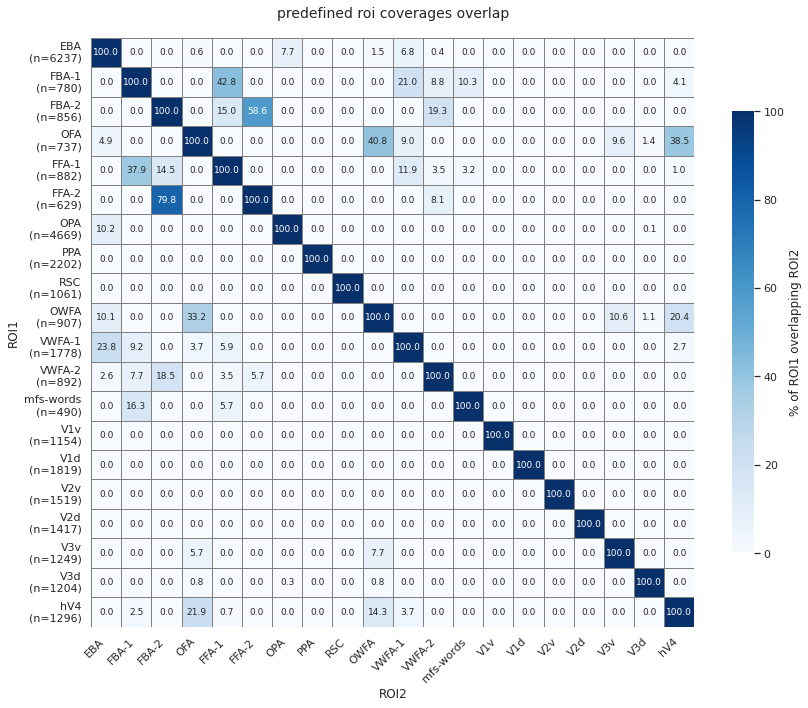

In [8]:
ROI_tsne_funcs.plot_ROI_overlap_heatmap_percentage(predefined_ROI_indices, "predefined roi coverages overlap")


### Here  I am jsut trying to see how much in general the nearest_center methods are changing the size of the ROI

In [6]:
import pandas

nearest_center_covareges = [config for config in roi_coverage_configs if (config.discrimination_method == 'predefined' or config.discrimination_method == 'nearest_center')]

data = {
    config.name: [len(config.inferred_ROI_indices_dict[roi]) for roi in ROI_names]
    for config in nearest_center_covareges
}
df = pandas.DataFrame(data, index=ROI_names)
df


,predefined,ms_euc_nearest_center,ms_cos_nearest_center
EBA,6237,4255,4139
FBA-1,780,1802,391
FBA-2,856,562,654
OFA,737,596,677
FFA-1,882,1010,1031
FFA-2,629,552,703
OPA,4669,6929,5885
PPA,2202,2742,2728
RSC,1061,1994,3120
OWFA,907,1451,1503


In [7]:

# Calculate the absolute difference from the predefined value for each ROI and method
predefined_sizes = df['predefined']
distances = df.drop(columns='predefined').apply(lambda col: (col - predefined_sizes))
distances


,ms_euc_nearest_center,ms_cos_nearest_center
EBA,-1982,-2098
FBA-1,1022,-389
FBA-2,-294,-202
OFA,-141,-60
FFA-1,128,149
FFA-2,-77,74
OPA,2260,1216
PPA,540,526
RSC,933,2059
OWFA,544,596


In [8]:
# Calculate the percentage difference from the predefined value for each ROI and method
percentage_distances = (distances.divide(df['predefined'], axis=0) * 100).round(2)
percentage_distances

,ms_euc_nearest_center,ms_cos_nearest_center
EBA,-31.78,-33.64
FBA-1,131.03,-49.87
FBA-2,-34.35,-23.60
OFA,-19.13,-8.14
FFA-1,14.51,16.89
FFA-2,-12.24,11.76
OPA,48.40,26.04
PPA,24.52,23.89
RSC,87.94,194.06
OWFA,59.98,65.71


In [9]:
mean_percentage_diff = percentage_distances.mean(axis=0).round(2)
std_percentage_diff = percentage_distances.std(axis=0).round(2)

print("Mean percentage difference from predefined for each method:")
print(mean_percentage_diff)
print("\nStandard deviation of percentage difference from predefined for each method:")
print(std_percentage_diff)

Mean percentage difference from predefined for each method:
ms_euc_nearest_center    40.34
ms_cos_nearest_center    41.49
dtype: float64

Standard deviation of percentage difference from predefined for each method:
ms_euc_nearest_center    62.16
ms_cos_nearest_center    67.73
dtype: float64


In [20]:
mean_per_method = distances.mean(axis=0)
std_per_method = distances.std(axis=0)

print("Mean distance from predefined for each method:")
print(mean_per_method)
print("\nVariance of distance from predefined for each method:")
print(std_per_method)


Mean distance from predefined for each method:
ms_euc_nearest_center    388.5
ms_cos_nearest_center    388.5
dtype: float64

Variance of distance from predefined for each method:
ms_euc_nearest_center    825.947399
ms_cos_nearest_center    824.764943
dtype: float64


In [12]:
tenzor_dir = '/home/matanyaw/data/roi_coverages_tenzors/'

for coverage in roi_coverage_configs:
        coverage.save_into_tezor(save_path=tenzor_dir)

In [18]:
# now let's load the tenzor
tenzor = torch.load(tenzor_dir + roi_coverage_configs[2].name + '.pt')
tenzor

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.int8)

In [20]:
roi_names = ROI_coverage.get_roi_names(subject=1)
row = roi_names.index('FFA-1')
row

ROI 'mTL-bodies' not found for subject 1
ROI 'mTL-faces' not found for subject 1
ROI 'aTL-faces' not found for subject 1
ROI 'mTL-words' not found for subject 1


4

In [19]:
tenzor.shape
for roi_idx, roi_name in enumerate(ROI_names):
    print(tenzor[roi_idx, :].sum())


tensor(6237)
tensor(780)
tensor(856)
tensor(737)
tensor(882)
tensor(629)
tensor(4669)
tensor(2202)
tensor(1061)
tensor(907)
tensor(1778)
tensor(892)
tensor(490)
tensor(1154)
tensor(1819)
tensor(1519)
tensor(1417)
tensor(1249)
tensor(1204)
tensor(1296)


In [ ]:
# num_voxels = voxel_embeddings.shape[0]
# num_rois = len(ROI_names)
# roi_tensor = torch.zeros((num_rois, num_voxels), dtype=torch.int8)

# roi_tensor[0, 0:1000] = 1
# roi_tensor[1, 1000:2000] = 1
# roi_tensor[2, 2000:3000] = 1
# roi_tensor[3, 3000:4000] = 1
# roi_tensor[4, 4000:5000] = 1
# roi_tensor[5, 5000:6000] = 1
# roi_tensor[6, 6000:7000] = 1
# roi_tensor[7, 7000:8000] = 1
# roi_tensor[8, 8000:9000] = 1

# torch.save(roi_tensor, '/home/matanyaw/data/roi_coverages_tenzors/test_tenzor.pt')
